In [28]:
import os

from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Annotated, List, Optional
from langchain_core.messages import BaseMessage, HumanMessage
from langgraph.graph.message import add_messages
from langchain_huggingface import HuggingFacePipeline, ChatHuggingFace
from langchain_deepseek import ChatDeepSeek
from langgraph.checkpoint.sqlite import SqliteSaver
import sqlite3

from langgraph.prebuilt import ToolNode, tools_condition
from langchain_core.tools import tool
import yfinance as yf
from langchain_community.tools import DuckDuckGoSearchRun, WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper
from pydantic import BaseModel, Field
from datetime import date, timedelta
from dotenv import load_dotenv
load_dotenv()

api_key = os.getenv("DEEPSEEK_API_KEY")

In [17]:
# Inbuilt tools
duck_search = DuckDuckGoSearchRun()
wiki_search = WikipediaQueryRun(api_wrapper=WikipediaAPIWrapper())

# custom tool
class StockInput(BaseModel):
    ticker_name: str = Field(
        ...,
        description="Stock ticker symbol used by Yahoo Finance. Use the exchange-specific ticker when required, e.g. AAPL for Apple (US), RELIANCE.NS for Reliance Industries (NSE India), or TCS.NS for TCS (NSE India)."
    )
    Date: date = Field(
        default_factory=date.today,
        description="The trading date for which the historical closing price is requested. Use the date in YYYY-MM-DD format. If the user does not specify a date, use today's date."
    )


class StockOutput(BaseModel):
    ticker_name: str = Field(
        ...,
        description="The stock ticker symbol used to retrieve the historical price."
    )
    Date: date = Field(
        ...,
        description="The date for which the historical stock price was retrieved, in YYYY-MM-DD format."
    )
    closing_Price: float = Field(
        ...,
        description="The stock's closing market price on the specified trading date."
    )


@tool(args_schema=StockInput)
def StockPriceSearch(ticker_name: str, Date: date) -> StockOutput:
    """Get the historical closing price of a stock for a specific trading date.

    Use this tool when the user asks for the stock price or closing price
    of a particular company on a specific date.

    The ticker_name must be a Yahoo Finance ticker symbol.
    The Date specifies the trading date for which the closing price is required.

    If the specified date is not a trading day, such as a weekend or market holiday,
    no historical price may be available.
    """
    ticker_name = ticker_name.upper()
    stock_data = yf.Ticker(ticker_name).history(start=Date, end=Date + timedelta(days=1))

    return StockOutput(
        ticker_name=ticker_name,
        Date=Date,
        closing_Price=float(stock_data["Close"].iloc[0])
    )
# StockPriceSearch.invoke({"ticker_name": "AAPL", "Date": "2026-03-31"})

In [18]:
# chat model
chat_model = ChatDeepSeek(api_key=api_key, model="deepseek-v4-flash")
chat_model_with_tools = chat_model.bind_tools([duck_search, wiki_search, StockPriceSearch])

In [19]:
# state
class ChatState(TypedDict):
    messages: Annotated[List[BaseMessage], add_messages]

In [20]:
# chat node func
def chat_node(state: ChatState):
    response = chat_model_with_tools.invoke(input=state["messages"])
    return {"messages" : [response]}

In [30]:
# checkpointer
conn = sqlite3.connect(database="testing.db", check_same_thread=False)
checkpointer = SqliteSaver(conn=conn)

# tool node
tool_node = ToolNode([duck_search, wiki_search, StockPriceSearch])

In [42]:
# graph
graph = StateGraph(ChatState)
graph.add_node("chat_node", chat_node)
graph.add_node("tools", tool_node)

graph.add_edge(START, "chat_node")
graph.add_conditional_edges("chat_node", tools_condition)
graph.add_edge("tools", "chat_node")

chatbot = graph.compile(checkpointer=checkpointer)

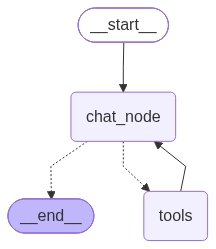

In [43]:
chatbot

In [46]:
# invoke
initial_state = {"messages": [HumanMessage(content="What was sindoor operation by india and any latest operation?")]}
CONFIG = {"configurable": {"thread_id": "jayesh"}}
response_state = chatbot.invoke(input=initial_state, config=CONFIG)

In [47]:
response_state

{'messages': [HumanMessage(content='What was sindoor operation by india and any latest operation?', additional_kwargs={}, response_metadata={}, id='fc4cd623-9203-48b4-b730-26ff8fa12d4a'),
  AIMessage(content='', additional_kwargs={'refusal': None, 'reasoning_content': 'The user is asking about "Sindoor Operation" by India and any latest operation. Let me think about this. There\'s "Operation Sindoor" which is a recent Indian military operation against Pakistan in May 2025, in response to the Pahalgam terror attack. Let me search for more information.\n\nLet me search for this.'}, response_metadata={'token_usage': {'completion_tokens': 158, 'prompt_tokens': 745, 'total_tokens': 903, 'completion_tokens_details': {'accepted_prediction_tokens': None, 'audio_tokens': None, 'reasoning_tokens': 70, 'rejected_prediction_tokens': None, 'text_tokens': None}, 'prompt_tokens_details': {'audio_tokens': None, 'cache_write_tokens': None, 'cached_tokens': 640, 'image_tokens': None, 'text_tokens': None